<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/iris_decision_tree_classification_english.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-class Classification with Decision Trees (Iris Dataset)

In this notebook, we will implement a decision tree multi-class classification model for the Iris dataset using Python's scikit-learn library. We will proceed through the following steps:

1. Import necessary libraries
2. Load and explore the dataset
3. Preprocess the data
4. Train the decision tree model
5. Evaluate the model
6. Visualize the decision tree
7. Tune hyperparameters

## 1. Import Necessary Libraries

In [1]:
# Data processing and analysis libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

# Graph settings
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Load and Explore the Dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Check basic dataset information
print(f"Dataset size: {X.shape}")
print(f"Class labels: {np.unique(y)}")
print(f"Class names: {iris.target_names}")
print(f"Feature names: {iris.feature_names}")

Dataset size: (150, 4)
Class labels: [0 1 2]
Class names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
# Convert to DataFrame for easier data exploration
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# Check data samples
print("Data samples:")
iris_df.head()

Data samples:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Check descriptive statistics
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


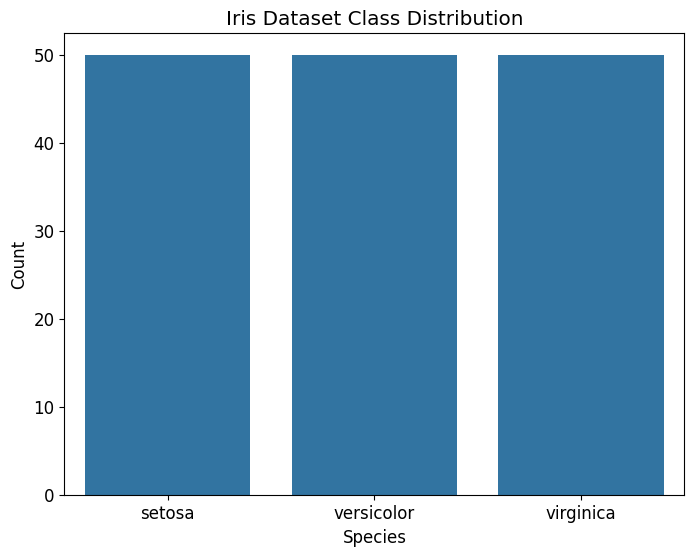

In [5]:
# Check class distribution
print("Class distribution:")
print(iris_df['species'].value_counts())

# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=iris_df)
plt.title('Iris Dataset Class Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

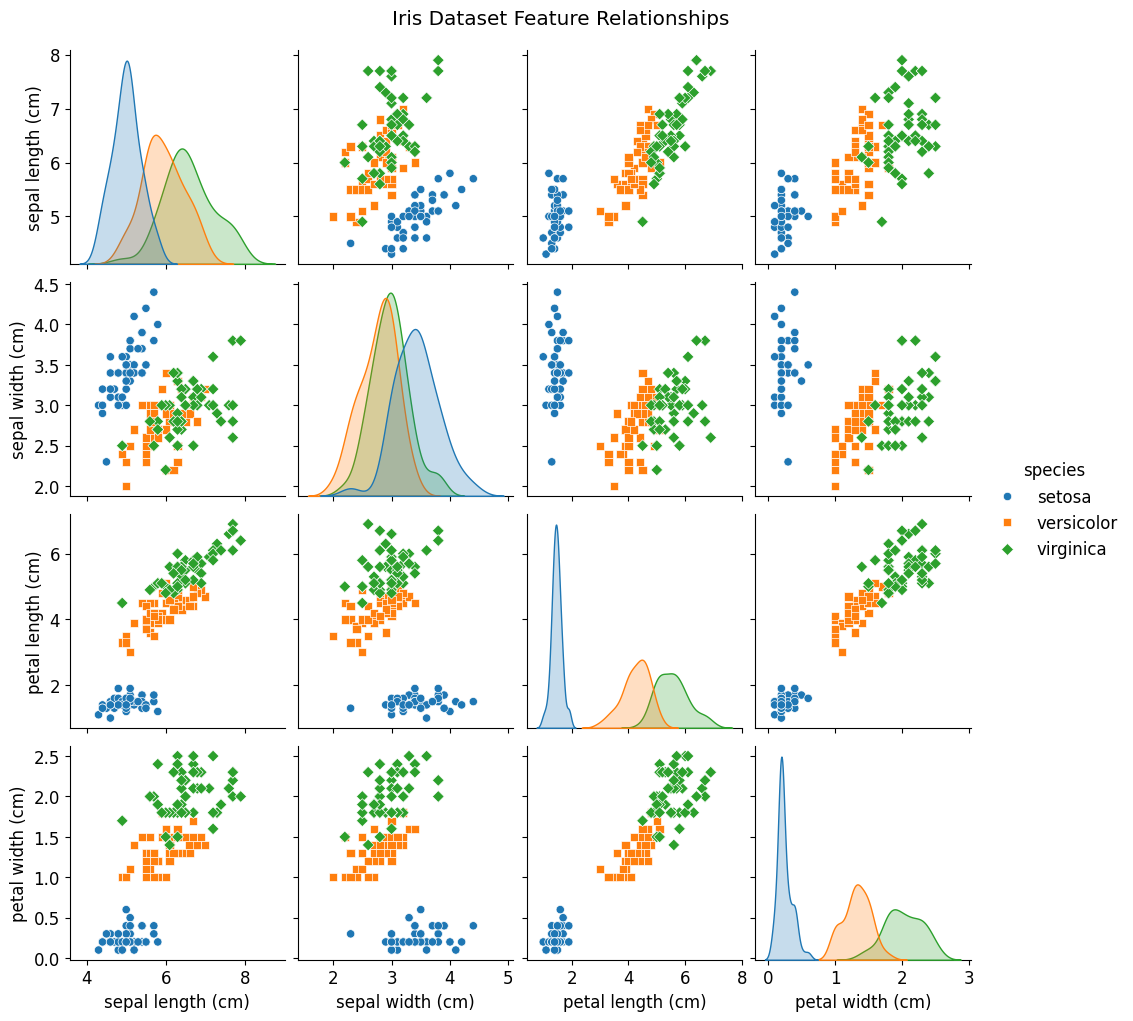

In [6]:
# Visualize relationships between features (pairplot)
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Iris Dataset Feature Relationships', y=1.02)
plt.show()

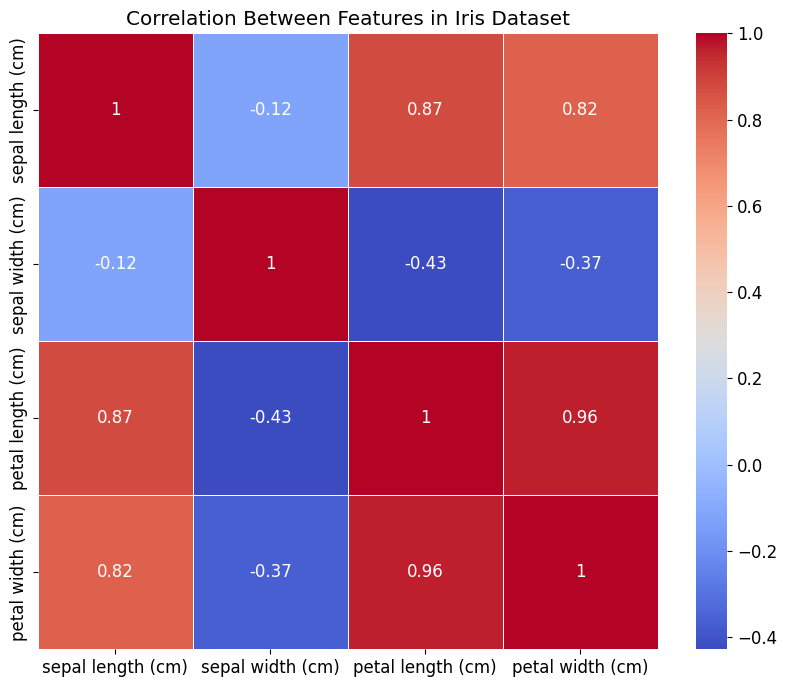

In [7]:
# Correlation analysis
plt.figure(figsize=(10, 8))
correlation = iris_df.drop('species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Features in Iris Dataset')
plt.show()

## 3. Data Preprocessing

In [8]:
# Split into training and test sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check split results
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Check class distribution in training set
unique, counts = np.unique(y_train, return_counts=True)
print("Training set class distribution:", dict(zip(iris.target_names, counts)))

# Check class distribution in test set
unique, counts = np.unique(y_test, return_counts=True)
print("Test set class distribution:", dict(zip(iris.target_names, counts)))

Training set size: (120, 4)
Test set size: (30, 4)
Training set class distribution: {np.str_('setosa'): np.int64(40), np.str_('versicolor'): np.int64(40), np.str_('virginica'): np.int64(40)}
Test set class distribution: {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(10), np.str_('virginica'): np.int64(10)}


In [9]:
# Feature scaling (optional - decision trees are not affected by scaling, but included for educational purposes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compare before and after scaling
print("Training data before scaling (first 5 samples):")
print(X_train[:5])
print("\nTraining data after scaling (first 5 samples):")
print(X_train_scaled[:5])

Training data before scaling (first 5 samples):
[[4.4 2.9 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [6.8 2.8 4.8 1.4]
 [4.9 3.1 1.5 0.1]
 [5.5 2.5 4.  1.3]]

Training data after scaling (first 5 samples):
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


## 4. Train the Decision Tree Model

In [10]:
# Create and train a basic decision tree model (using original data)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Print model information
print(f"Decision tree depth: {dt_classifier.get_depth()}")
print(f"Number of nodes: {dt_classifier.tree_.node_count}")
print(f"Number of leaf nodes: {dt_classifier.tree_.n_leaves}")

Decision tree depth: 5
Number of nodes: 15
Number of leaf nodes: 8


## 5. Evaluate the Model

In [11]:
# Predictions on training set
y_train_pred = dt_classifier.predict(X_train)

# Predictions on test set
y_test_pred = dt_classifier.predict(X_test)

# Evaluate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training set accuracy: {train_accuracy:.4f}")
print(f"Test set accuracy: {test_accuracy:.4f}")

Training set accuracy: 1.0000
Test set accuracy: 0.9333


In [12]:
# Classification report (precision, recall, F1-score)
print("Test set classification report:")
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))

Test set classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



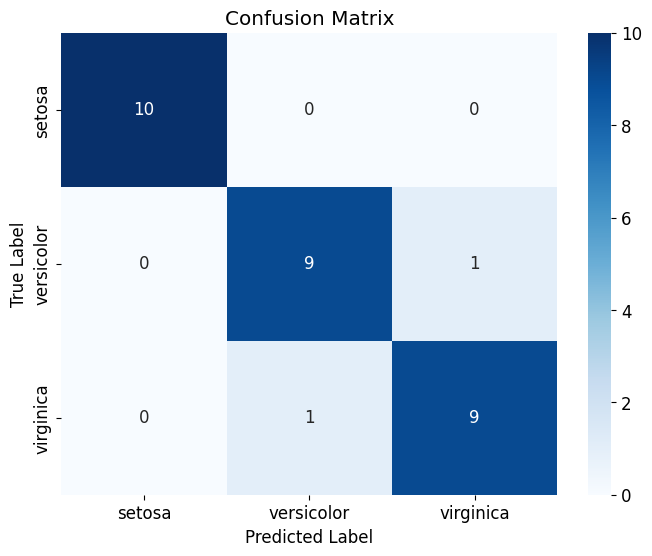

In [13]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Feature importance:
             feature  importance
2  petal length (cm)    0.558568
3   petal width (cm)    0.406015
1   sepal width (cm)    0.029167
0  sepal length (cm)    0.006250


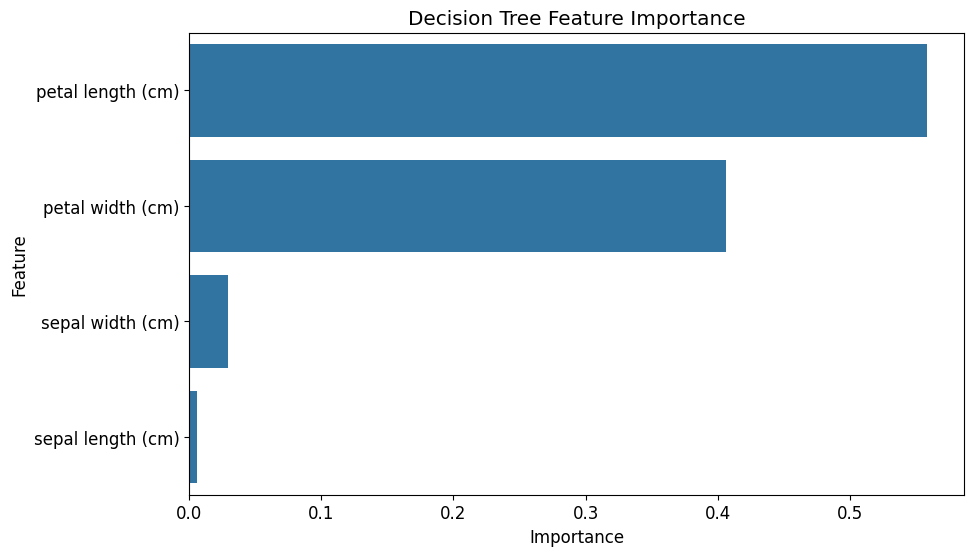

In [14]:
# Check feature importance
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 6. Visualize the Decision Tree

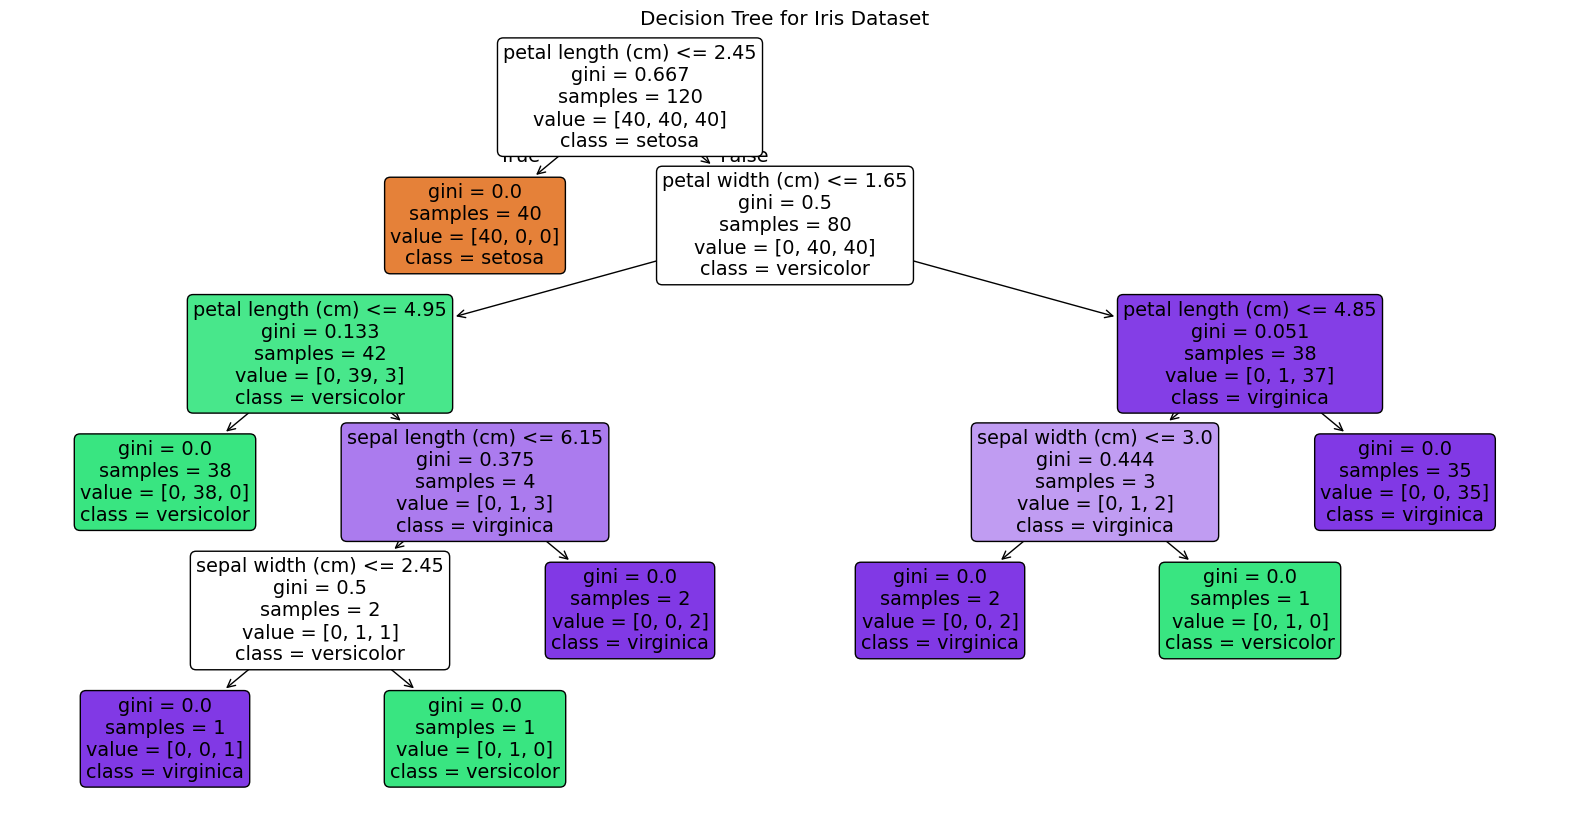

In [15]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title('Decision Tree for Iris Dataset')
plt.show()

## 7. Hyperparameter Tuning

In [16]:
# Hyperparameter tuning using grid search
param_grid = {
    'max_depth': [None, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print optimal hyperparameters and performance
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.9417


In [17]:
# Evaluate the best model on the test set
best_dt = grid_search.best_estimator_
y_test_pred_best = best_dt.predict(X_test)
best_test_accuracy = accuracy_score(y_test, y_test_pred_best)

print(f"Best model test set accuracy: {best_test_accuracy:.4f}")
print("\nBest model test set classification report:")
print(classification_report(y_test, y_test_pred_best, target_names=iris.target_names))

Best model test set accuracy: 0.9333

Best model test set classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



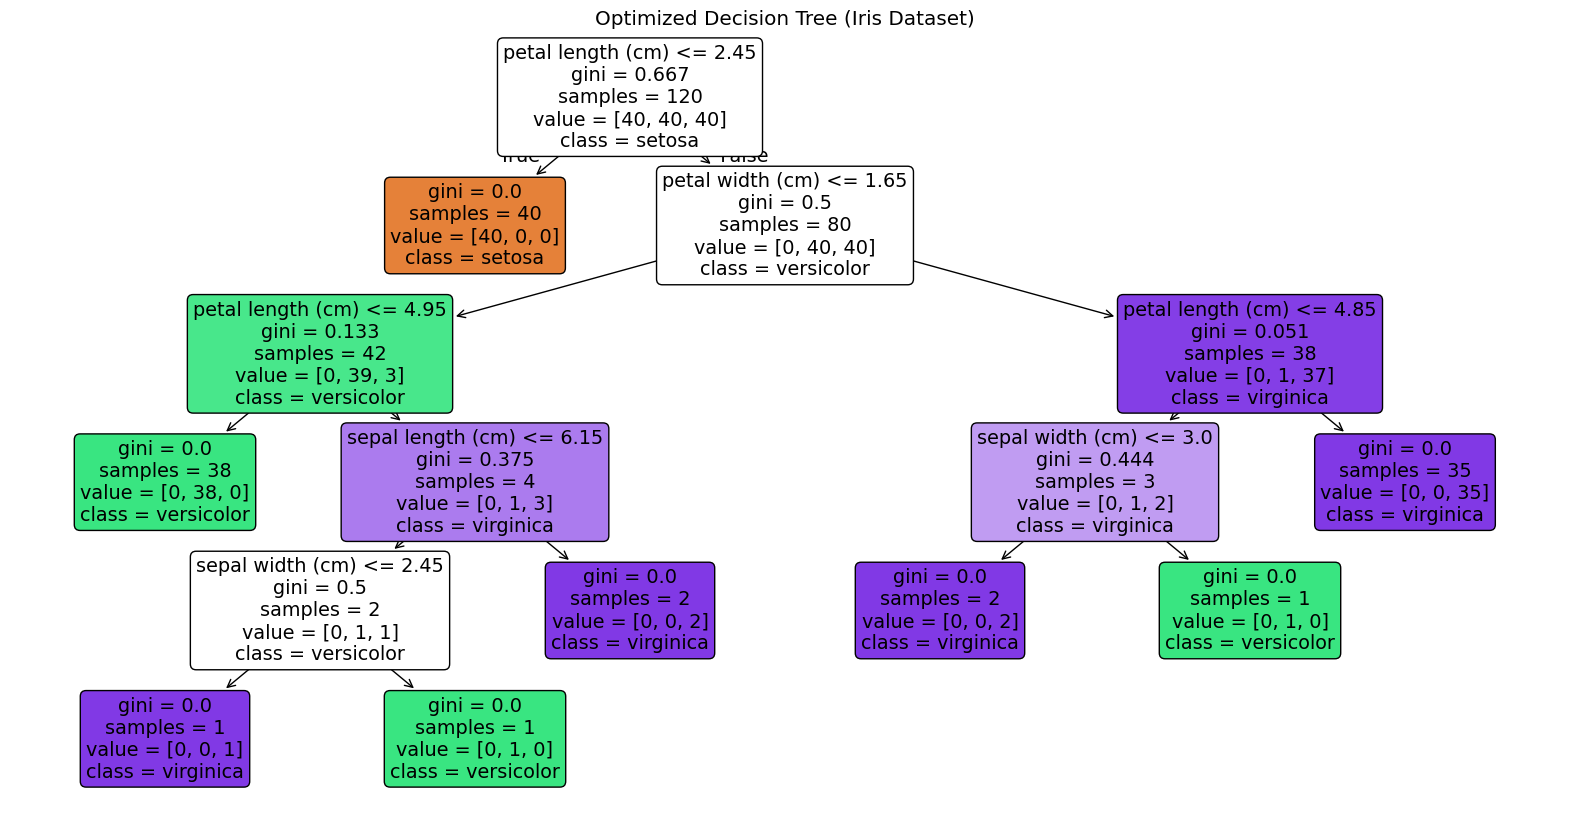

In [18]:
# Visualize the optimized decision tree
plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title('Optimized Decision Tree (Iris Dataset)')
plt.show()

## 8. Predictions on New Data

In [19]:
# Create new data samples
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],  # similar to setosa
    [6.7, 3.1, 4.7, 1.5],  # similar to versicolor
    [6.3, 3.3, 6.0, 2.5]   # similar to virginica
])

# Make predictions
predictions = best_dt.predict(new_samples)
prediction_proba = best_dt.predict_proba(new_samples)

# Print results
print("Predictions for new data:")
for i, (sample, pred, proba) in enumerate(zip(new_samples, predictions, prediction_proba)):
    print(f"Sample {i+1}: {sample}")
    print(f"  Predicted class: {iris.target_names[pred]}")
    print(f"  Class probabilities: {dict(zip(iris.target_names, proba))}")
    print()

Predictions for new data:
Sample 1: [5.1 3.5 1.4 0.2]
  Predicted class: setosa
  Class probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}

Sample 2: [6.7 3.1 4.7 1.5]
  Predicted class: versicolor
  Class probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(1.0), np.str_('virginica'): np.float64(0.0)}

Sample 3: [6.3 3.3 6.  2.5]
  Predicted class: virginica
  Class probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(1.0)}



## 9. Conclusion and Summary

In this notebook, we implemented a decision tree multi-class classification model for the Iris dataset. The key steps and findings are as follows:

1. **Data Exploration**: The Iris dataset contains 3 classes (setosa, versicolor, virginica) with 4 features, and the classes are evenly distributed.

2. **Model Training**: We trained a basic decision tree model and improved its performance through hyperparameter tuning.

3. **Model Evaluation**: The optimized model showed high accuracy on the test set, with perfect classification for the setosa class.

4. **Feature Importance**: The most important features in the decision tree model were petal length and petal width.

5. **Visualization**: We visualized the decision tree to understand the model's decision-making process.

Decision trees have the advantage of being interpretable and visualizable, making them effective for multi-class classification problems. However, they can be prone to overfitting, so proper hyperparameter tuning is important.